An attempt at trying to remove persistence from images.

Using the idea that persistence signals (from previous observation ROSs) should be present in each dither and each filter, but with some decay over time.

In [ ]:
import numpy as np
import os
import pandas as pd
from astropy.convolution import convolve
from astropy.io import fits
from glob import glob
from matplotlib import pyplot as plt
from photutils.segmentation import deblend_sources, detect_sources, detect_threshold, make_2dgaussian_kernel, SourceCatalog
from scipy.ndimage import binary_opening, median_filter

from nicl.utilities import read_fits_to_dataset

In [ ]:
path = "/Users/spb/data/euclid/q1/clusters/MCXC_J1743.3+6440"

In [ ]:
def get_nisp_images(path):
    fns = sorted(glob(os.path.join(path, "EUC_NIR*Z.fits")))
    info = dict(filename=fns, filter=[], obs_id=[], mjd=[])
    for fn in fns:
        with fits.open(fn) as f:
            h = f[0].header
            info["filter"].append(h["FILTER"])
            info["obs_id"].append(h["OBS_ID"])
            info["mjd"].append(h["MJD-OBS"])
    images = pd.DataFrame(info)
    return images

In [ ]:
def minimum_map(fns, extname):
    images = np.dstack([fits.getdata(f, extname=extname) for f in fns])
    # Could apply a bad pixel mask here
    images_sorted = np.sort(images, axis=-1)
    minimum = images_sorted[..., 0]
    minimum_err = images_sorted[..., 1] - minimum
    min_med = np.median(minimum, axis=(0, 1))
    minimum -= min_med
    return minimum, minimum_err

In [ ]:
def dq_map(fns, extname):
    extname = extname.replace("SCI", "DQ")
    hdr = fits.getheader(fns.iloc[0], extname)
    dq_masks = {h.replace("MSK_FLAG_", ""): hdr[h] for h in hdr if h.startswith("MSK_FLAG")}
    dqs = np.dstack([fits.getdata(f, extname=extname) for f in fns])
    masks = {m: (dqs & 2**bit > 0).any(axis=-1) for m, bit in dq_masks.items()}
    return masks

In [ ]:
images = get_nisp_images(path)
images = images.sort_values("mjd")

In [ ]:
images

,filename,filter,obs_id,mjd
8,/Users/spb/data/euclid/q1/clusters/MCXC_J1743....,J,2070,60474.810460
0,/Users/spb/data/euclid/q1/clusters/MCXC_J1743....,H,2070,60474.812011
16,/Users/spb/data/euclid/q1/clusters/MCXC_J1743....,Y,2070,60474.813562
9,/Users/spb/data/euclid/q1/clusters/MCXC_J1743....,J,2070,60474.822798
1,/Users/spb/data/euclid/q1/clusters/MCXC_J1743....,H,2070,60474.824350
17,/Users/spb/data/euclid/q1/clusters/MCXC_J1743....,Y,2070,60474.825900
10,/Users/spb/data/euclid/q1/clusters/MCXC_J1743....,J,2070,60474.835136
2,/Users/spb/data/euclid/q1/clusters/MCXC_J1743....,H,2070,60474.836687
18,/Users/spb/data/euclid/q1/clusters/MCXC_J1743....,Y,2070,60474.838238
11,/Users/spb/data/euclid/q1/clusters/MCXC_J1743....,J,2070,60474.847474


In [ ]:
fits.info(images.filename.iloc[0])

Filename: /Users/spb/data/euclid/q1/clusters/MCXC_J1743.3+6440/EUC_NIR_W-CAL-IMAGE_J-2070-0_20240706T085944.202082Z.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     114   ()      
  1  DET11.SCI     1 ImageHDU        92   (2040, 2040)   float32   
  2  DET11.RMS     1 ImageHDU        41   (2040, 2040)   float32   
  3  DET11.DQ      1 ImageHDU        68   (2040, 2040)   int32 (rescales to uint32)   
  4  DET21.SCI     1 ImageHDU        92   (2040, 2040)   float32   
  5  DET21.RMS     1 ImageHDU        41   (2040, 2040)   float32   
  6  DET21.DQ      1 ImageHDU        68   (2040, 2040)   int32 (rescales to uint32)   
  7  DET31.SCI     1 ImageHDU        92   (2040, 2040)   float32   
  8  DET31.RMS     1 ImageHDU        41   (2040, 2040)   float32   
  9  DET31.DQ      1 ImageHDU        68   (2040, 2040)   int32 (rescales to uint32)   
 10  DET41.SCI     1 ImageHDU        92   (2040, 2040)   float32   
 11  DET41.RMS     1 ImageHDU

In [ ]:
images.groupby(["obs_id", "filter"])[["mjd"]].mean()

mjd
obs_id filter              
2070   H       60474.830519
       J       60474.828967
       Y       60474.832069
2071   H       60474.881919
       J       60474.880368
       Y       60474.883470

In [ ]:
def get_primary_header(images):
    hdr = fits.Header()
    mismatch = set()
    for fn in images.filename:
        newhdr = fits.getheader(fn)
        for h in newhdr:
            if h not in hdr:
                try:
                    hdr[h] = newhdr[h]
                except ValueError:
                    pass
            elif hdr[h] != newhdr[h]:
                mismatch.add(h)
    for h in mismatch:
        hdr.remove(h)
    return hdr

In [ ]:
def calc_persistence_info(images, ext):
    exthdr = fits.Header([("EXTNAME", ext)])
    primary_header = get_primary_header(images)
    for obs_id, obs_info in images.groupby("obs_id"):
        minimum_img = {}
        for filter, img_info in obs_info.groupby("filter"):
            minimum, minimum_err = minimum_map(img_info.filename, extname=ext)
            minimum_img[filter] = minimum
            #fits.append(os.path.join(path, f"minimum_{obs_id}_{filter}.fits"), minimum, exthdr)
            #fits.append(os.path.join(path, f"minimum_err_{obs_id}_{filter}.fits"), minimum_err, exthdr)
            #dq_masks = dq_map(img_info.filename, ext)
            #for m, dqm in dq_masks.items():
            #    fits.append(os.path.join(path, f"dq_{m}_{obs_id}_{filter}.fits"), dqm.astype(int), exthdr)
        #ratioJH = minimum_img["J"] / minimum_img["H"]
        #ratioHY = minimum_img["H"] / minimum_img["Y"]
        #diffJH = minimum_img["J"] - minimum_img["H"]
        #diffHY = minimum_img["H"] - minimum_img["Y"]
        #fits.append(os.path.join(path, f"ratioJH_{obs_id}.fits"), ratioJH, extname=ext)
        #fits.append(os.path.join(path, f"ratioHY_{obs_id}.fits"), ratioHY, extname=ext)
        #fits.append(os.path.join(path, f"diffJH_{obs_id}.fits"), diffJH, extname=ext)
        #fits.append(os.path.join(path, f"diffHY_{obs_id}.fits"), diffHY, extname=ext)
        medmin = np.median(list(minimum_img.values()), axis=0)
        medmin_fn = os.path.join(path, f"medmin_{obs_id}.fits")
        if not os.path.exists(medmin_fn):
            fits.append(medmin_fn, None, primary_header)
        fits.append(medmin_fn, medmin, exthdr)
        for _, img_info in obs_info.iterrows():
            img = fits.getdata(img_info.filename, extname=ext)
            img -= medmin
            sub_fn = img_info.filename.replace(".fits", ".sub1.fits")
            if not os.path.exists(sub_fn):
                fits.append(sub_fn, None, primary_header)
            fits.append(sub_fn, img, fits.getheader(img_info.filename, extname=ext))
        mad = np.median(np.abs(medmin))
        mask = ((medmin / mad) > 1)
        fits.append(os.path.join(path, f"medminmask_{obs_id}.fits"), mask.astype(int), exthdr)
        mask_closed = binary_opening(mask, iterations=2)
        fits.append(os.path.join(path, f"medminclosedmask_{obs_id}.fits"), mask_closed.astype(int), exthdr)

In [ ]:
def calc_rolling_persistence_info(images, ext, n_roll=4):
    exthdr = fits.Header([("EXTNAME", ext)])
    primary_header = get_primary_header(images)
    for i in range(n_roll):
        obs_info = images.iloc[3*i:3*i + 3*n_roll]
        obs_id = obs_info.iloc[0].obs_id
        minimum_img = {}
        for filter, img_info in obs_info.groupby("filter"):
            minimum, minimum_err = minimum_map(img_info.filename, extname=ext)
            minimum_img[filter] = minimum
            j = "JHY".index(filter)
            min_fn = os.path.join(path, f"min_{obs_id}_{i}_{j}_{filter}.fits")
            if not os.path.exists(min_fn):
                fits.append(min_fn, None, primary_header)
            fits.append(min_fn, minimum, exthdr)
        medmin = np.median(list(minimum_img.values()), axis=0)
        medmin_fn = os.path.join(path, f"medmin_{obs_id}_{i}.fits")
        if not os.path.exists(medmin_fn):
            fits.append(medmin_fn, None, primary_header)
        fits.append(medmin_fn, medmin, exthdr)
        for _, img_info in obs_info[:3].iterrows():
            img = fits.getdata(img_info.filename, extname=ext)
            img -= medmin
            sub_fn = img_info.filename.replace(".fits", ".sub2.fits")
            if not os.path.exists(sub_fn):
                fits.append(sub_fn, None, primary_header)
            fits.append(sub_fn, img, fits.getheader(img_info.filename, extname=ext))

In [ ]:
dets = [f"DET{i}{j}" for j in range(1, 5) for i in range(1, 5)]
sci_exts = [f"{d}.SCI" for d in dets]
sci_exts = ["DET44.SCI"]

In [ ]:
%%time 
for ext in sci_exts:
    calc_persistence_info(images, ext)

CPU times: user 28.3 s, sys: 6.53 s, total: 34.8 s
Wall time: 42.8 s


In [ ]:
%%time 
for ext in sci_exts:
    calc_rolling_persistence_info(images, ext)

CPU times: user 13.4 s, sys: 1.62 s, total: 15 s
Wall time: 15.8 s


In [ ]:
fns = glob(os.path.join(path, "min_*.fits"))
fns = sorted(fns)

In [ ]:
mean_img = None
for fn in fns:
    img = fits.getdata(fn)
    if mean_img is None:
        mean_img = img
    else:
        mean_img += img
mean_img /= len(fns)
fits.writeto(os.path.join(path, "mean_img.fits"), mean_img, overwrite=True)

In [ ]:
bkg = median_filter(mean_img, 25)
mean_img_bkg_sub = mean_img - bkg
fits.writeto(os.path.join(path, "mean_img_bkg_sub.fits"), mean_img_bkg_sub, overwrite=True)

In [ ]:
threshold = detect_threshold(mean_img_bkg_sub, nsigma=1.0)
kernel = make_2dgaussian_kernel(2.0, size=7)
det_img = convolve(mean_img_bkg_sub, kernel)
segm = detect_sources(
    data=det_img,
    threshold=threshold,
    npixels=9,
)
segm_deblend = deblend_sources(
    det_img,
    segm,
    npixels=9,
    nlevels=32,
    contrast=0.1,
    progress_bar=True,
)
fits.writeto(os.path.join(path, "segm.fits"), segm.data, overwrite=True)
fits.writeto(os.path.join(path, "segm_deblend.fits"), segm_deblend.data, overwrite=True)

Deblending:   0%|          | 0/977 [00:00<?, ?it/s]

In [ ]:
fits.writeto(os.path.join(path, "segm.fits"), segm.data, overwrite=True)
fits.writeto(os.path.join(path, "segm_deblend.fits"), segm_deblend.data, overwrite=True)

In [ ]:
segm_fluxes = []
for fn in fns:
    img = fits.getdata(fn)
    cat = SourceCatalog(img, segm)
    segm_fluxes.append(cat.segment_flux)

In [ ]:
segm_fluxes = np.array(segm_fluxes)

In [ ]:
norm = segm_fluxes[-3:].mean(axis=0)

In [ ]:
segm_fluxes_norm = segm_fluxes #/ norm

In [ ]:
t = images.mjd[9:-3]

In [ ]:
seg_id_old_dots = [1702] 
seg_id_old_lines = [1399]
seg_id_new_dots = [1364] 
seg_id_new_lines = [1392]

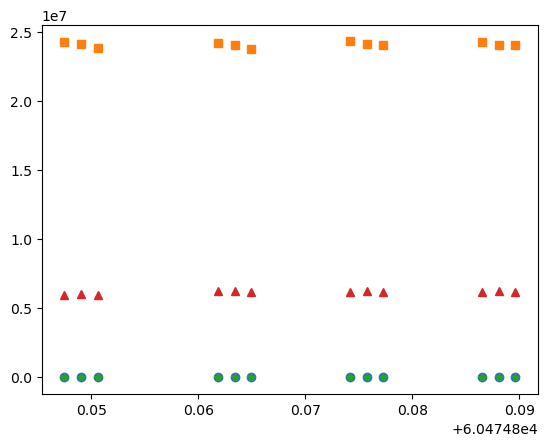

In [ ]:
plt.plot(t, segm_fluxes_norm[:, seg_id_old_dots], 'o')
plt.plot(t, segm_fluxes_norm[:, seg_id_old_lines], 's')
plt.plot(t, segm_fluxes_norm[:, seg_id_new_dots], '*')
plt.plot(t, segm_fluxes_norm[:, seg_id_new_lines], '^');

Get persistence masks created by the NISP pipeline.

In [ ]:
for img_info in images.iterrows():
    dq = fits.getdata(img_info["filename"], extname="DET11.DQ")
    dqp = dq & 2**13 > 0
    fits.writeto(img_info["filename"].replace(".fits", ".dqp.fits"), dqp.astype("uint8"), overwrite=True)

TypeError: cannot unpack non-iterable int object

Use the mask of persistence features to look at how persistence regions vary with time.

In [ ]:
persistence_values = {"J": [], "H": [], "Y": []}
for (obs_id, filter), img_info in images.iterrows():
    mask = fits.getdata(os.path.join(path, f"medminclosedmask_{obs_id}.fits")) > 0
    img = fits.getdata(img_info["filename"])
    img -= np.median(img)
    persistence_values[filter].append(img[mask])

In [ ]:
for filter in "JHY":
    plt.hist(persistence_values[filter], histtype="step", range=[-50, 150], bins=100,
             color=plt.cm.jet(np.linspace(0, 1, 8)))

Compute slope and look at distibution. This is too simple, as some persistence features appear during ROS.

In [ ]:
slope = {}
for filter in "JHY":
    p = persistence_values[filter]
    slope[filter] = p[3] + p[2] - p[1] - p[0]
plt.hist(slope["J"], histtype="step", range=(-200, 200), bins=100, color="g")
plt.hist(slope["H"], histtype="step", range=(-200, 200), bins=100, color="r")
plt.hist(slope["Y"], histtype="step", range=(-200, 200), bins=100, color="b");

slope = np.mean(list(slope.values()), axis=0)
plt.hist(slope, histtype="step", range=(-200, 200), bins=100, color="k", lw=2);
plt.axvline(0, color="k", linestyle=":");